# LLMProver Results Analysis
Interactive exploration of proof results, Isabelle code, and input data.

In [1]:
import json
import re
from pathlib import Path
from collections import defaultdict

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display, HTML, Markdown
import ipywidgets as widgets

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_colwidth', 120)

## 1. Load results

In [2]:
RESULTS_ROOT = Path('results')

# List available runs
runs = sorted([p for p in RESULTS_ROOT.iterdir() if p.is_dir()])
for r in runs:
    n = len(list(r.glob('*_results.json')))
    print(f'{r.name}  ({n} files)')

Codestral-22B-v0.1_no_scheme  (146 files)
Codestral-22B-v0.1_scheme  (140 files)
Qwen2.5-Coder-32B_no_scheme  (200 files)
Qwen2.5-Coder-32B_scheme  (200 files)
gemma-4-31B-it_no_scheme  (12 files)
gemma-4-31B-it_scheme  (7 files)


In [ ]:
# Set the run to analyse
RUN = runs[2]   # change index or set RUN = RESULTS_ROOT / 'my_run_id'
print('Analysing:', RUN)

records = []
for f in sorted(RUN.glob('*_results.json')):
    try:
        records.append(json.loads(f.read_text()))
    except Exception as e:
        print(f'  skip {f.name}: {e}')
print(f'Loaded {len(records)} records')

Analysing: results/Codestral-22B-v0.1_no_scheme
Loaded 146 records


In [4]:
import ast

def flatten(rec):
    r = rec.get('results', {})
    return {
        'id':               rec.get('id'),
        'topic':            rec.get('topic', ''),
        'scheme':           rec.get('argumentation_scheme', 'unknown'),
        'stance':           rec.get('stance', ''),
        'premise':          rec.get('premise', ''),
        'hypothesis':       rec.get('hypothesis', ''),
        'explanation':      rec.get('explanation', ''),
        'ground_truth':     rec.get('ground_truth_premise', '') or rec.get('removed_premise', ''),
        'gt_type':          rec.get('ground_truth_premise_type', '') or rec.get('removed_premise_type', ''),
        'valid':            bool(r.get('semantic validity', False)) and not bool(r.get('auto_asserted_axioms')),
        'iteration':        r.get('refined iteration'),
        'gen_premises_nl':  r.get('nl_generated_premises', ''),
        'gen_premises':     r.get('refined generated premises', ''),
        'isabelle_code':    r.get('refined_isabelle_code', ''),
        'history':          r.get('history critique output', []),
        'n_unsolved':       len(r.get('unsolved_goals') or []),
        'has_bridge':       bool(r.get('bridge_new_consts')),
        'auto_asserted':    bool(r.get('auto_asserted_axioms')),
        '_raw':             rec,
    }

df = pd.DataFrame([flatten(r) for r in records])
print(df.shape)
df[['id','scheme','valid','iteration']].head()

(146, 19)


,id,scheme,valid,iteration
0,1007_variant_0,inconsistent commitment,False,1.0
1,1030_variant_1,threat,False,1.0
2,104_variant_1,slippery slope,False,1.0
3,1067_variant_0,sign,False,0.0
4,1077_variant_2,witness testimony,True,0.0


In [5]:
_TYPE_ERROR_PATTERNS = [
    'Type unification failed', 'Clash of types', 'Type error in application',
    'Undeclared', 'Undefined',
    'Inner syntax error', 'Failed to parse', 'Bad context for command',
]

def _has_type_error(entry: dict) -> bool:
    tactics = str(entry.get('proof tactics', []))
    return any(p in tactics for p in _TYPE_ERROR_PATTERNS)

_IS_SCHEME_RUN = 'no_scheme' not in RUN.name

def classify_failure(row):
    if row['valid']:
        return None

    history = row['history']
    if history:
        try:
            first = ast.literal_eval(history[0].split(': ', 1)[1])
            if not first.get('syntactic validity', True) or _has_type_error(first):
                return 'syntax error'
        except Exception:
            pass

    # Auto-asserted goals count as scheme failures — but only for scheme runs.
    # Base model auto-asserts are a bug (fixed in main.py) and should be ignored.
    if _IS_SCHEME_RUN and row['_raw'].get('results', {}).get('auto_asserted_axioms'):
        return 'unsolved goals'

    unsolved = list(row['_raw'].get('results', {}).get('unsolved_goals') or [])
    have_goals = [g for g in unsolved if '?thesis' not in g]
    bridge_insufficient = any('?thesis' in g for g in unsolved) or not unsolved

    if have_goals and bridge_insufficient:
        return 'unsolved goals + bridge insufficient'
    elif have_goals:
        return 'unsolved goals'
    else:
        return 'bridge insufficient'

df['failure_type'] = df.apply(classify_failure, axis=1)
print(df['failure_type'].value_counts())


failure_type
syntax error           97
bridge insufficient    47
Name: count, dtype: int64


## 2. Overall statistics

In [6]:
total   = len(df)
n_valid = df['valid'].sum()
print(f'Total examples : {total}')
print(f'Proved (valid) : {n_valid}  ({n_valid/total:.1%})')
print(f'Failed         : {total - n_valid}  ({(total-n_valid)/total:.1%})')
if df['iteration'].notna().any():
    print(f'Mean iterations: {df["iteration"].mean():.2f}  (max {df["iteration"].max():.0f})')

Total examples : 146
Proved (valid) : 2  (1.4%)
Failed         : 144  (98.6%)
Mean iterations: 0.68  (max 1)


## 3. Success rate by scheme

,total,proved,success_rate
scheme,,,
ignorance,7,1,14.3%
witness testimony,10,1,10.0%
precedent,7,0,0.0%
waste,10,0,0.0%
verbal classification,7,0,0.0%
threat,10,0,0.0%
sunk costs,8,0,0.0%
slippery slope,10,0,0.0%
sign,8,0,0.0%


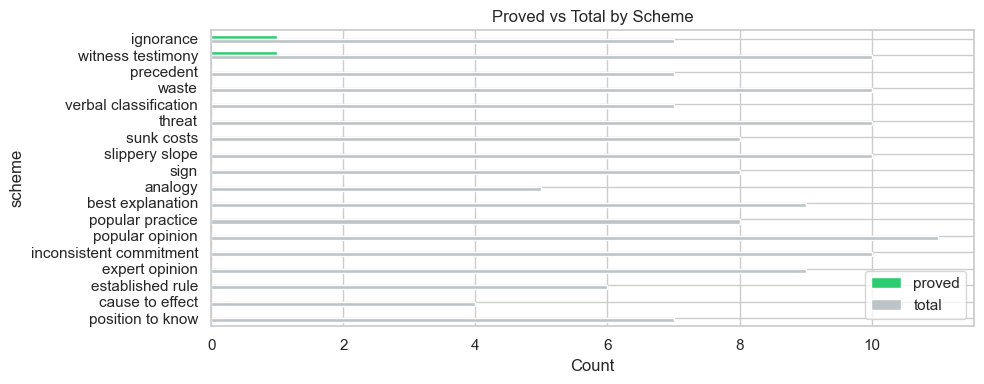

In [7]:
scheme_stats = (
    df.groupby('scheme')['valid']
      .agg(total='count', proved='sum')
      .assign(success_rate=lambda x: x['proved'] / x['total'])
      .sort_values('success_rate', ascending=False)
)
display(scheme_stats.style.format({'success_rate': '{:.1%}'}).background_gradient(subset='success_rate', cmap='RdYlGn'))

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#2ecc71' if v else '#e74c3c' for v in [True, False]]
scheme_stats[['proved', 'total']].plot.barh(ax=ax, color=['#2ecc71','#bdc3c7'])
ax.set_xlabel('Count')
ax.set_title('Proved vs Total by Scheme')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [8]:
# ── LaTeX table: scheme vs baseline success rate ──────────────────────────────────────
# Ordered from highest to lowest scheme success rate, wrapping into two columns.
# Detects the paired baseline run automatically (foo_scheme <-> foo_no_scheme).

def _load_run(run_dir):
    recs = [json.loads(f.read_text()) for f in sorted(run_dir.glob('*_results.json'))]
    return pd.DataFrame([flatten(r) for r in recs])

def _scheme_success_rates(d):
    return (
        d.groupby('scheme')['valid']
         .agg(total='count', proved='sum')
         .assign(rate=lambda x: x['proved'] / x['total'])
    )['rate']

s_rates = _scheme_success_rates(df)

_base_dir = RESULTS_ROOT / RUN.name.replace('_scheme', '_no_scheme')
if _base_dir.exists():
    _base_df = _load_run(_base_dir)
    b_rates  = _scheme_success_rates(_base_df)
    print(f'Paired baseline: {_base_dir.name}')
else:
    b_rates = pd.Series(dtype=float)
    print('No paired baseline found — B column will be empty.')

all_schemes = sorted(
    set(s_rates.index) | set(b_rates.index),
    key=lambda s: -s_rates.get(s, 0.0)
)

def _fmt_scheme(s):
    mapping = {'inconsistent commitment': r'Inconsist.\ commitment'}
    return mapping.get(s, s.title())

def _fmt_pct(val):
    return '' if pd.isna(val) else f'{val * 100:.1f}'

half  = (len(all_schemes) + 1) // 2
left  = all_schemes[:half]
right = all_schemes[half:] + [None] * (half - len(all_schemes[half:]))

rows = []
for ls, rs in zip(left, right):
    row = (
        _fmt_scheme(ls), _fmt_pct(s_rates.get(ls)), _fmt_pct(b_rates.get(ls)),
        _fmt_scheme(rs) if rs else '',
        _fmt_pct(s_rates.get(rs)) if rs else '',
        _fmt_pct(b_rates.get(rs)) if rs else '',
    )
    rows.append(row)

model_label = RUN.name.split('_scheme')[0].replace('_', '-')

lines = [
    r'\begin{table}[th]',
    r'\centering',
    r'\small',
    r'\begin{tabular}{lcc lcc}',
    r'\toprule',
    (r'\textbf{Scheme} & \textbf{S} & \textbf{B} & '
     r'\textbf{Scheme} & \textbf{S} & \textbf{B} \\'),
    r'\midrule',
]
for ln, ls, lb, rn, rs, rb in rows:
    lines.append(f'{ln:<30} & {ls:>5} & {lb:>5} & {rn:<30} & {rs:>5} & {rb:>5} \\\\')
lines += [
    r'\bottomrule',
    r'\end{tabular}',
    (r'\caption{Success rate of (S)cheme vs (B)aseline approaches by '
     f'argumentation scheme ({model_label}).' + r'}'),
    r'\label{tab:scheme_success}',
    r'\end{table}',
]

print('\n'.join(lines))


No paired baseline found — B column will be empty.
\begin{table}[th]
\centering
\small
\begin{tabular}{lcc lcc}
\toprule
\textbf{Scheme} & \textbf{S} & \textbf{B} & \textbf{Scheme} & \textbf{S} & \textbf{B} \\
\midrule
Ignorance                      &  14.3 &       & Popular Opinion                &   0.0 &       \\
Witness Testimony              &  10.0 &       & Analogy                        &   0.0 &       \\
Expert Opinion                 &   0.0 &       & Slippery Slope                 &   0.0 &       \\
Verbal Classification          &   0.0 &       & Waste                          &   0.0 &       \\
Precedent                      &   0.0 &       & Cause To Effect                &   0.0 &       \\
Sunk Costs                     &   0.0 &       & Sign                           &   0.0 &       \\
Popular Practice               &   0.0 &       & Established Rule               &   0.0 &       \\
Position To Know               &   0.0 &       & Best Explanation               &   0.0 

,total,proved,success_rate
stance,,,
against,68,2,2.9%
in favor,78,0,0.0%


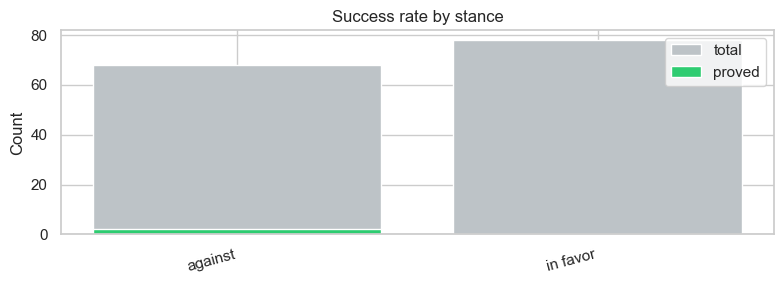

In [9]:
stance_stats = (
    df[df['stance'].str.strip().ne('')]
      .groupby('stance')['valid']
      .agg(total='count', proved='sum')
      .assign(success_rate=lambda x: x['proved'] / x['total'])
      .sort_values('success_rate', ascending=False)
)
display(stance_stats.style.format({'success_rate': '{:.1%}'}).background_gradient(subset='success_rate', cmap='RdYlGn'))

fig, ax = plt.subplots(figsize=(8, 3))
x = range(len(stance_stats))
ax.bar(x, stance_stats['total'],  color='#bdc3c7', label='total')
ax.bar(x, stance_stats['proved'], color='#2ecc71', label='proved')
ax.set_xticks(list(x))
ax.set_xticklabels(stance_stats.index, rotation=15, ha='right')
ax.set_ylabel('Count')
ax.set_title('Success rate by stance')
ax.legend()
plt.tight_layout()
plt.show()

## 3b. Success rate by stance

## 4. Iteration distribution

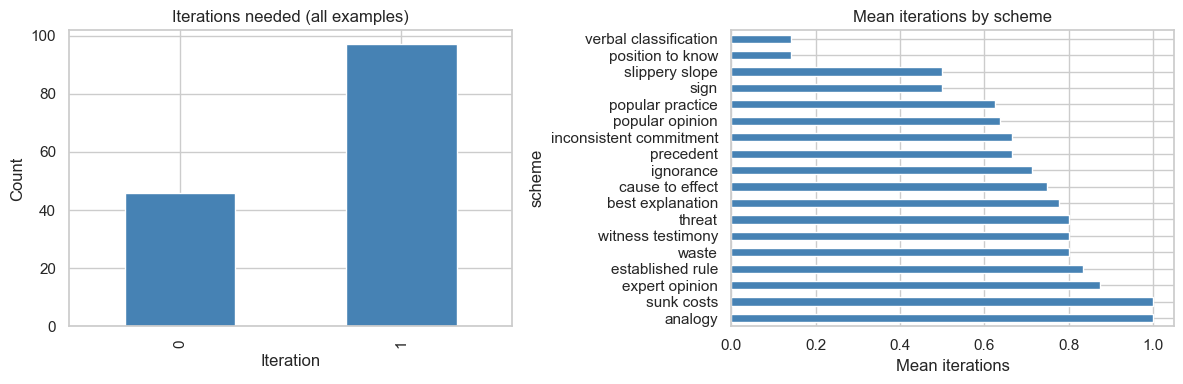

In [10]:
iter_data = df[df['iteration'].notna()]
if not iter_data.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Overall histogram
    iter_data['iteration'].astype(int).value_counts().sort_index().plot.bar(ax=axes[0], color='steelblue')
    axes[0].set_title('Iterations needed (all examples)')
    axes[0].set_xlabel('Iteration')
    axes[0].set_ylabel('Count')

    # Mean per scheme
    iter_by_scheme = iter_data.groupby('scheme')['iteration'].mean().sort_values()
    iter_by_scheme.plot.barh(ax=axes[1], color='steelblue')
    axes[1].set_title('Mean iterations by scheme')
    axes[1].set_xlabel('Mean iterations')
    axes[1].invert_yaxis()

    plt.tight_layout()
    plt.show()
else:
    print('No iteration data')

## 5. Failure type analysis

,total,bridge_insufficient,rate
scheme,,,
position to know,7,6,85.7%
verbal classification,7,6,85.7%
sign,8,4,50.0%
slippery slope,10,5,50.0%
precedent,7,3,42.9%
inconsistent commitment,10,4,40.0%
popular practice,8,3,37.5%
popular opinion,11,4,36.4%
cause to effect,4,1,25.0%


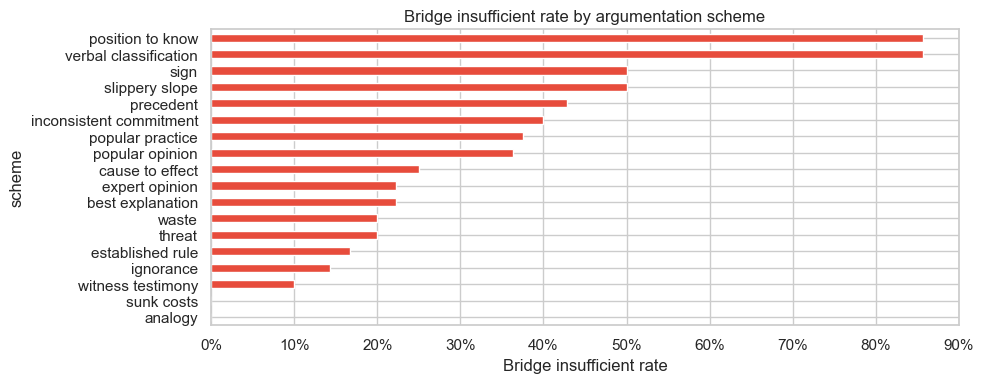

In [11]:
bridge_by_scheme = (
    df.groupby('scheme')
      .apply(lambda g: pd.Series({
          'total': len(g),
          'bridge_insufficient': (g['failure_type'].isin(['bridge insufficient', 'unsolved goals + bridge insufficient'])).sum(),
      }))
      .assign(rate=lambda x: x['bridge_insufficient'] / x['total'])
      .sort_values('rate', ascending=False)
)
display(bridge_by_scheme.style.format({'rate': '{:.1%}'}).background_gradient(subset='rate', cmap='Reds'))

fig, ax = plt.subplots(figsize=(10, 4))
bridge_by_scheme['rate'].plot.barh(ax=ax, color='#e74c3c')
ax.set_xlabel('Bridge insufficient rate')
ax.set_title('Bridge insufficient rate by argumentation scheme')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.invert_yaxis()
plt.tight_layout()
plt.show()

,total,proved,success_rate
shows_type,,,
atomic,25,2,8.0%
direct_implication,5,0,0.0%
existential,43,0,0.0%
forall_constraining,47,0,0.0%
forall_implication,25,0,0.0%
unknown,1,0,0.0%


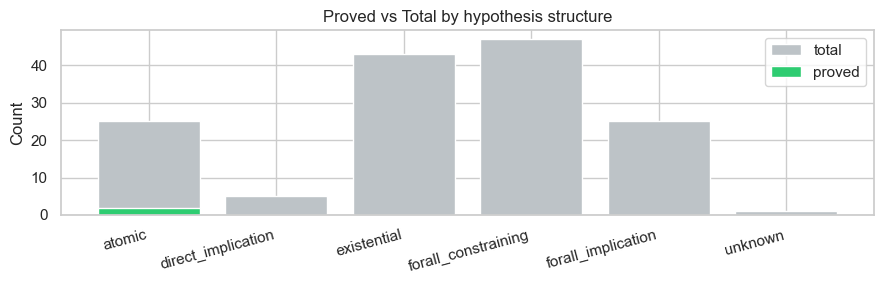

In [12]:
def classify_shows(isabelle_code: str) -> str:
    """Classify the structure of the shows clause.

    Categories:
    - existential       : outermost is ∃  (just find a witness)
    - forall_constraining: ∀x. SinglePred x --> ...  (forall only filters which x)
    - forall_implication : ∀x. ComplexAntecedent --> ...  (proving a general rule)
    - direct_implication : A --> B at top level, no outer quantifier
    - atomic             : no implication, no quantifier (direct fact)
    - unknown            : could not parse
    """
    if not isabelle_code:
        return 'unknown'
    m = re.search(r'shows\s+"([^"]+)"', isabelle_code)
    if not m:
        return 'unknown'
    shows = m.group(1).strip()

    has_imp   = '-->' in shows
    is_forall = shows.startswith('\\<forall>')
    is_exists = shows.startswith('\\<exists>')

    if is_exists:
        return 'existential'

    if not has_imp and not is_forall:
        return 'atomic'

    if not is_forall and has_imp:
        return 'direct_implication'

    if is_forall and has_imp:
        # Extract antecedent: strip leading ∀x. bindings then take text before first -->
        body = re.sub(r'^(\\<forall>[^.]+\.\s*)+', '', shows)
        antecedent = body.split('-->')[0].strip()
        # Constraining: antecedent is a single predicate application (no connectives)
        is_simple = not any(op in antecedent for op in ['\\<and>', '\\<or>', '\\<not>', '\\<exists>', '-->'])
        return 'forall_constraining' if is_simple else 'forall_implication'

    return 'atomic'  # forall without -->

df['shows_type'] = df['isabelle_code'].apply(classify_shows)

# Success rate by shows type
shows_stats = (
    df.groupby('shows_type')['valid']
      .agg(total='count', proved='sum')
      .assign(success_rate=lambda x: x['proved'] / x['total'])
      .sort_values('success_rate', ascending=False)
)
display(shows_stats.style.format({'success_rate': '{:.1%}'}).background_gradient(subset='success_rate', cmap='RdYlGn'))

# Bar chart
fig, ax = plt.subplots(figsize=(9, 3))
x = range(len(shows_stats))
ax.bar(x, shows_stats['total'],   color='#bdc3c7', label='total')
ax.bar(x, shows_stats['proved'],  color='#2ecc71', label='proved')
ax.set_xticks(list(x))
ax.set_xticklabels(shows_stats.index, rotation=15, ha='right')
ax.set_ylabel('Count')
ax.set_title('Proved vs Total by hypothesis structure')
ax.legend()
plt.tight_layout()
plt.show()

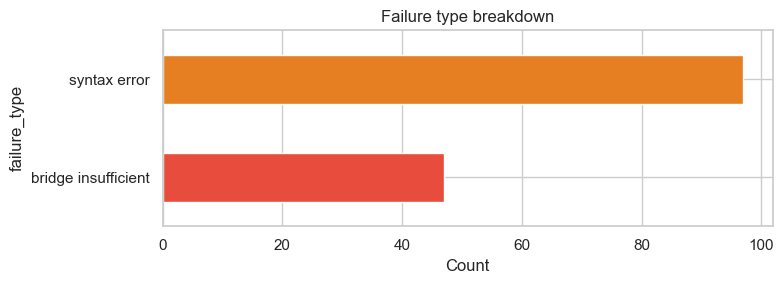

,count,% of all,% of failed
failure_type,,,
syntax error,97,66.4%,67.4%
bridge insufficient,47,32.2%,32.6%


In [13]:
_COLORS = {
    'bridge insufficient':              '#e74c3c',
    'unsolved goals':                   '#3498db',
    'unsolved goals + bridge insufficient': '#9b59b6',
    'syntax error':                     '#e67e22',
}

failure_counts = df[~df['valid']]['failure_type'].value_counts()

fig, ax = plt.subplots(figsize=(8, 3))
colors = [_COLORS.get(k, '#95a5a6') for k in failure_counts.index]
failure_counts.plot.barh(ax=ax, color=colors)
ax.set_xlabel('Count')
ax.set_title('Failure type breakdown')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Summary table
_total = len(df)
_n_failed = (~df['valid']).sum()
_rows = []
for ft, cnt in failure_counts.items():
    _rows.append({
        'failure_type': ft,
        'count': int(cnt),
        '% of all': f'{cnt/_total:.1%}',
        '% of failed': f'{cnt/_n_failed:.1%}' if _n_failed > 0 else '—',
    })
display(pd.DataFrame(_rows).set_index('failure_type'))

## 5. Pretty-print an example
Use the widget below to browse individual results.

In [14]:
from IPython.display import clear_output

ISABELLE_KW = re.compile(
    r'\b(theory|imports|begin|end|typedecl|consts|axiomatization|where|theorem|assumes|shows|proof|qed|oops|sorry|have|show|then|using|by|obtain|apply|insert|sledgehammer|from|let|in)\b'
)
ISABELLE_SYMBOLS = re.compile(r'(\\&lt;[a-zA-Z]+&gt;|--&gt;|==&gt;|&lt;--&gt;|!!)')

def highlight_isabelle(code: str) -> str:
    if not code:
        return '<em style="color:#999">No Isabelle code available</em>'
    lines = []
    for line in code.splitlines():
        line = line.replace('&', '&amp;').replace('<', '&lt;').replace('>', '&gt;')
        line = re.sub(r'"[^"]*?"', lambda m: f'<span style=\'color:#2980b9\'>{m.group(0)}</span>', line)
        line = ISABELLE_KW.sub(lambda m: f'<span style=\'color:#8e44ad;font-weight:bold\'>{m.group(0)}</span>', line)
        line = ISABELLE_SYMBOLS.sub(lambda m: f'<span style=\'color:#e67e22\'>{m.group(0)}</span>', line)
        if '(*' in line:
            line = re.sub(r'(\(\*.*?\*\))', lambda m: f'<span style=\'color:#888;font-style:italic\'>{m.group(0)}</span>', line)
        lines.append(line)
    body = '\n'.join(lines)
    return (f'<pre style="background:#f8f8f8;border:1px solid #ddd;border-radius:4px;'
            f'padding:12px;font-size:12px;line-height:1.5;overflow-x:auto">{body}</pre>')


def render_example(idx: int):
    row = df.iloc[idx]
    status_color = '#27ae60' if row['valid'] else '#c0392b'
    status_text  = '✓ PROVED' if row['valid'] else '✗ FAILED'

    nl = row['gen_premises_nl']
    if isinstance(nl, list):
        nl = '\n'.join(str(x) for x in nl)
    gen_premises_display = nl or row['gen_premises'] or '<em>none</em>'
    if nl:
        gen_premises_display = gen_premises_display.replace('\n', '<br>')

    html = f"""
    <div style="font-family:sans-serif;max-width:900px">
      <h2 style="border-bottom:2px solid #3498db;padding-bottom:6px">
        Example {idx+1}/{len(df)} &nbsp;
        <span style="color:{status_color};font-size:14px">{status_text}</span>
      </h2>
      <table style="width:100%;border-collapse:collapse;margin-bottom:12px">
        <tr><td style="width:160px;color:#555;vertical-align:top"><b>ID</b></td><td>{row['id']}</td></tr>
        <tr><td><b>Topic</b></td><td>{row['topic']}</td></tr>
        <tr><td><b>Scheme</b></td>
            <td><code style="background:#eaf2ff;padding:2px 6px;border-radius:3px">{row['scheme']}</code></td></tr>
        <tr><td><b>Iteration</b></td><td>{row['iteration']}</td></tr>
      </table>
      <h3 style="color:#2c3e50">Input</h3>
      <table style="width:100%;border-collapse:collapse">
        <tr style="background:#f0f4f8">
          <td style="padding:8px;vertical-align:top;width:120px"><b>Premise</b></td>
          <td style="padding:8px">{row['premise'] or '<em>none</em>'}</td></tr>
        <tr>
          <td style="padding:8px;vertical-align:top"><b>Hypothesis</b></td>
          <td style="padding:8px">{row['hypothesis']}</td></tr>
        <tr style="background:#f0f4f8">
          <td style="padding:8px;vertical-align:top"><b>Explanation</b></td>
          <td style="padding:8px">{row['explanation'] or '<em>none</em>'}</td></tr>
        <tr>
          <td style="padding:8px;vertical-align:top"><b>Ground truth</b></td>
          <td style="padding:8px"><em style="color:#7f8c8d">{row['gt_type']}</em><br>{row['ground_truth'] or '<em>none</em>'}</td></tr>
        <tr style="background:#f0f4f8">
          <td style="padding:8px;vertical-align:top"><b>Gen premises</b></td>
          <td style="padding:8px">{gen_premises_display}</td></tr>
      </table>
      <h3 style="color:#2c3e50;margin-top:16px">Isabelle Theory</h3>
      {highlight_isabelle(row['isabelle_code'])}
    </div>
    """
    display(HTML(html))


clear_output(wait=True)

slider = widgets.IntSlider(value=0, min=0, max=len(df)-1, description='Example', layout=widgets.Layout(width='500px'))
out = widgets.Output()

def _on_change(change):
    with out:
        out.clear_output(wait=True)
        render_example(change['new'])

slider.observe(_on_change, names='value')
display(widgets.VBox([slider, out]))
with out:
    render_example(0)

## 6. Filter & search

In [15]:
clear_output(wait=True)

# --- Filter controls ---
scheme_opts = ['(all)'] + sorted(df['scheme'].unique().tolist())
scheme_dd = widgets.Dropdown(options=scheme_opts, description='Scheme')
valid_dd  = widgets.Dropdown(options=['(all)', 'proved', 'failed'], description='Status')
search_box = widgets.Text(placeholder='keyword in hypothesis/premise/topic', description='Search', layout=widgets.Layout(width='400px'))
out2 = widgets.Output()

def apply_filters(*_):
    mask = pd.Series([True] * len(df))
    if scheme_dd.value != '(all)':
        mask &= df['scheme'] == scheme_dd.value
    if valid_dd.value == 'proved':
        mask &= df['valid']
    elif valid_dd.value == 'failed':
        mask &= ~df['valid']
    if search_box.value.strip():
        kw = search_box.value.strip().lower()
        mask &= (
            df['hypothesis'].str.lower().str.contains(kw, na=False) |
            df['premise'].str.lower().str.contains(kw, na=False) |
            df['topic'].str.lower().str.contains(kw, na=False)
        )
    filtered = df[mask][['id','scheme','topic','valid','iteration']].reset_index(drop=True)
    with out2:
        out2.clear_output(wait=True)
        display(HTML(f'<b>{len(filtered)}</b> examples match'))
        display(filtered.style.map(
            lambda v: 'color:green;font-weight:bold' if v is True else ('color:red' if v is False else ''),
            subset=['valid']
        ))

for w in (scheme_dd, valid_dd, search_box):
    w.observe(apply_filters, names='value')

display(widgets.HBox([scheme_dd, valid_dd, search_box]), out2)
apply_filters()

Output()

## 7. Refinement history for one example

In [16]:
def _extract_axioms(code: str) -> list[tuple[str, str]]:
    """Extract (name, formula) pairs from Isabelle code."""
    return re.findall(r'axiomatization\s+where\s+(\w+):\s*"([^"]+)"', code or '')

def _escape(s: str) -> str:
    return s.replace('&', '&amp;').replace('<', '&lt;').replace('>', '&gt;')

def show_history(idx: int):
    row = df.iloc[idx]
    history = row['history']
    raw_results = row['_raw'].get('results', {})
    auto_asserted = set(raw_results.get('auto_asserted_axioms') or [])

    if not history:
        display(HTML('<em>No history available</em>'))
        return

    status_color = '#27ae60' if row['valid'] else '#c0392b'
    status_text  = '✓ PROVED' if row['valid'] else '✗ FAILED'

    premise_list = row['premise'] if isinstance(row['premise'], list) else [row['premise']]
    premise_html = ''.join(f'<li>{_escape(p)}</li>' for p in premise_list if p)
    display(HTML(f"""
    <div style="font-family:sans-serif;max-width:900px;border:1px solid #ddd;border-radius:6px;padding:14px;margin-bottom:12px;background:#f9f9f9">
      <b>ID:</b> {row['id']} &nbsp; <span style="color:{status_color}">{status_text}</span><br><br>
      <b>Given premises:</b><ul style="margin:4px 0 8px 20px">{premise_html}</ul>
      <b>Hypothesis (conclusion):</b> {_escape(row['hypothesis'])}
    </div>
    """))

    display(Markdown(f'**Refinement iterations** ({len(history)} total)'))

    prev_axiom_names: set[str] = set()
    for i, entry in enumerate(history):
        try:
            parsed = ast.literal_eval(entry.split(': ', 1)[1])
        except Exception:
            continue

        valid    = parsed.get('semantic validity', False)
        unsolved = parsed.get('unsolved_goals', [])
        time     = parsed.get('solving time', 0)
        code     = parsed.get('code', '')

        cur_axioms = _extract_axioms(code)
        new_axioms = [(name, formula) for name, formula in cur_axioms if name not in prev_axiom_names]
        prev_axiom_names = {name for name, _ in cur_axioms}

        color = '#27ae60' if valid else '#c0392b'
        label = 'PROVED' if valid else 'failed'

        added_html = ''
        if new_axioms:
            items = ''
            for name, formula in new_axioms:
                if name in auto_asserted:
                    tag = '<span style="background:#fff3cd;color:#856404;border-radius:3px;padding:1px 5px;font-size:11px;margin-right:6px">auto-asserted</span>'
                else:
                    tag = '<span style="background:#d1ecf1;color:#0c5460;border-radius:3px;padding:1px 5px;font-size:11px;margin-right:6px">LLM</span>'
                items += f'<li style="font-family:monospace;font-size:12px;margin:3px 0">{tag}{_escape(formula)}</li>'
            added_html = f'<br><em>Added premises:</em><ul style="margin:4px 0 4px 20px">{items}</ul>'

        unsolved_html = ''
        if unsolved:
            items = ''.join(f'<li><code>{_escape(g)}</code></li>' for g in unsolved)
            unsolved_html = f'<br><em>Unsolved subgoals:</em><ul style="margin:4px 0 4px 20px">{items}</ul>'

        display(HTML(
            f'<div style="border-left:4px solid {color};padding:6px 14px;margin:8px 0;background:#fafafa;font-family:sans-serif">'
            f'<b>Iteration {i}</b> — <span style="color:{color}">{label}</span>'
            f'<span style="color:#888;font-size:12px;margin-left:12px">({time:.1f}s)</span>'
            + added_html + unsolved_html +
            '</div>'
        ))

# Show history for the first failed example
failed_idx = df[~df['valid']].index
show_history(failed_idx[0] if len(failed_idx) else 0)

**Refinement iterations** (6 total)

## 8. Compare two runs side-by-side

In [17]:
def load_run(run_dir: Path) -> pd.DataFrame:
    recs = [json.loads(f.read_text()) for f in sorted(run_dir.glob('*_results.json'))]
    return pd.DataFrame([flatten(r) for r in recs])

if len(runs) >= 2:
    dfA = load_run(runs[-2]).set_index('id')
    dfB = load_run(runs[-1]).set_index('id')
    common = dfA.index.intersection(dfB.index)
    comp = pd.DataFrame({
        runs[-2].name: dfA.loc[common, 'valid'],
        runs[-1].name: dfB.loc[common, 'valid'],
    })
    comp['delta'] = comp.iloc[:, 1].astype(int) - comp.iloc[:, 0].astype(int)
    improved = (comp['delta'] == 1).sum()
    regressed = (comp['delta'] == -1).sum()
    print(f'Common examples: {len(common)}')
    print(f'Improved (fail→pass): {improved}')
    print(f'Regressed (pass→fail): {regressed}')
    display(comp[comp['delta'] != 0].head(20))
else:
    print('Need at least 2 runs to compare')

Common examples: 7
Improved (fail→pass): 3
Regressed (pass→fail): 0


,gemma-4-31B-it_no_scheme,gemma-4-31B-it_scheme,delta
id,,,
223_variant_1,False,True,1
265_variant_1,False,True,1
472_variant_1,False,True,1
